#### В этом ноуте хочу сравнить оценки GARCH-EVA с Гумбелем/GARCH-EVT с фиттингом GPD/GARCH-EVT с фитингом GEV

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels as sm 
import seaborn as sns
from scipy.stats import norm
from scipy.optimize import minimize

np.random.seed(42)

In [6]:
## генерация GARCH

def garch_11_norm_sample(N, omega, alpha, beta): # функция генерации с норм инновациями

    z = np.random.normal(loc=0.0, scale=1.0, size=N) # инновации

    y = np.zeros(N) # массивы генерации
    sigma2 = np.zeros(N) # массивы генерации

    # оценка \sigma_0^2 как безусловная дисперсия процесса 
    unconditional_var = omega / (1 - alpha - beta)
    sigma2[0] = unconditional_var
    y[0] = np.sqrt(sigma2[0]) * z[0]

    # рекурсивное заполнение массива
    for t in range(1, N):
        # Уравнение дисперсии
        sigma2[t] = omega + alpha * (y[t-1]**2) + beta * sigma2[t-1]
        # Значение самого ряда
        y[t] = np.sqrt(sigma2[t]) * z[t]

    return y, np.sqrt(sigma2), z

def garch_11_stud_sample(N, omega, alpha, beta, df):

    # инновации с нормировкой
    z_raw = np.random.standard_t(df, size=N)
    z = z_raw * np.sqrt((df - 2) / df)

    y = np.zeros(N) # массивы генерации
    sigma2 = np.zeros(N) # массивы генерации

    # оценка \sigma_0^2 как безусловная дисперсия процесса 
    unconditional_var = omega / (1 - alpha - beta)
    sigma2[0] = unconditional_var
    y[0] = np.sqrt(sigma2[0]) * z[0]

    # рекурсивное заполнение массива
    for t in range(1, N):
        # Уравнение дисперсии
        sigma2[t] = omega + alpha * (y[t-1]**2) + beta * sigma2[t-1]
        # Значение самого ряда
        y[t] = np.sqrt(sigma2[t]) * z[t]

    return y, np.sqrt(sigma2), z
    


In [7]:
## дефолтная оценка GARCH через ММП

def estimate_garch11(x): 
    """
    input: x

    Параметры:
        omega > 0
        alpha >= 0
        beta >= 0
        alpha + beta < 1
    Args:
        x: array-like, одномерный временной ряд
    Returns:
        dict со следующими полями:
            omega: оценка omega
            alpha: оценка alpha
            beta: оценка beta
            loglik: значение лог-правдоподобия в оптимуме
            sigmas: оцененые условные стандартные отклоненя
    """
    x = np.asarray(x, dtype=float) 
    n = len(x)
    var_x = np.var(x)

    def compute_variances(params):
        omega, alpha, beta = params

        h = np.empty(n, dtype=float)

        # Инициализация условной дисперсии
        # Используем безусловную дисперсию, если модель стационарна
        denom = 1.0 - alpha - beta
        if denom <= 0:
            return None

        h0 = omega / denom
        if h0 <= 0 or not np.isfinite(h0):
            return None

        h[0] = h0

        for t in range(1, n):
            h[t] = omega + alpha * x[t - 1] ** 2 + beta * h[t - 1]
            if h[t] <= 0 or not np.isfinite(h[t]):
                return None

        return h

    def neg_loglik(params):
        omega, alpha, beta = params

        # Жёсткие ограничения
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
            return 1e20

        h = compute_variances(params)
        if h is None:
            return 1e20

        # Гауссово лог-правдоподобие
        ll = -0.5 * np.sum(np.log(2.0 * np.pi) + np.log(h) + (x ** 2) / h)

        return -ll

    # Начальные значения
    alpha0 = 0.2
    beta0 = 0.3
    omega0 = var_x * (1.0 - alpha0 - beta0)

    # Подстраховка
    omega0 = max(omega0, 1e-8)

    x0 = np.array([omega0, alpha0, beta0], dtype=float)

    # Границы для L-BFGS-B
    # Ограничение alpha + beta < 1 контролируем в целевой функции
    bounds = [
        (1e-12, None),   # omega > 0
        (0.0, 1.0),      # alpha >= 0
        (0.0, 1.0)       # beta >= 0
    ]

    result = minimize(
        neg_loglik,
        x0,
        method="L-BFGS-B",
        bounds=bounds
    )

    omega_hat, alpha_hat, beta_hat = result.x 
    loglik = -result.fun
    sigma_hat = compute_variances((omega_hat, alpha_hat, beta_hat))**0.5

    return {
        "omega": float(omega_hat),
        "alpha": float(alpha_hat),
        "beta": float(beta_hat),
        "loglik": float(loglik),
        "sigmas": sigma_hat
    }

In [ ]:
## дефолтная оценка GARCH через ММП с масштабированием

def scaling_estimate_garch11_norm(x): 
    """
    input: x

    Параметры:
        omega > 0
        alpha >= 0
        beta >= 0
        alpha + beta < 1
    Args:
        x: array-like, одномерный временной ряд
    Returns:
        dict со следующими полями:
            omega: оценка omega
            alpha: оценка alpha
            beta: оценка beta
            loglik: значение лог-правдоподобия в оптимуме
            sigmas: оцененые условные стандартные отклоненя
    """
    x = np.asarray(x * 100, dtype=float) # масштабируем для лучшей оценки
    n = len(x)
    var_x = np.var(x)

    def compute_variances(params):
        omega, alpha, beta = params

        h = np.empty(n, dtype=float)

        # Инициализация условной дисперсии
        # Используем безусловную дисперсию, если модель стационарна
        denom = 1.0 - alpha - beta
        if denom <= 0:
            return None

        h0 = omega / denom
        if h0 <= 0 or not np.isfinite(h0):
            return None

        h[0] = h0

        for t in range(1, n):
            h[t] = omega + alpha * x[t - 1] ** 2 + beta * h[t - 1]
            if h[t] <= 0 or not np.isfinite(h[t]):
                return None

        return h

    def neg_loglik(params):
        omega, alpha, beta = params

        # Жёсткие ограничения
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
            return 1e20

        h = compute_variances(params)
        if h is None:
            return 1e20

        # Гауссово лог-правдоподобие
        ll = -0.5 * np.sum(np.log(2.0 * np.pi) + np.log(h) + (x ** 2) / h)

        return -ll

    # Начальные значения
    alpha0 = 0.2
    beta0 = 0.3
    omega0 = var_x * (1.0 - alpha0 - beta0)

    # Подстраховка
    omega0 = max(omega0, 1e-8)

    x0 = np.array([omega0, alpha0, beta0], dtype=float)

    # Границы для L-BFGS-B
    # Ограничение alpha + beta < 1 контролируем в целевой функции
    bounds = [
        (1e-12, None),   # omega > 0
        (0.0, 1.0),      # alpha >= 0
        (0.0, 1.0)       # beta >= 0
    ]

    result = minimize(
        neg_loglik,
        x0,
        method="L-BFGS-B",
        bounds=bounds
    )

    omega_hat, alpha_hat, beta_hat = result.x 
    loglik = -result.fun
    sigma_hat = compute_variances((omega_hat, alpha_hat, beta_hat))**0.5 / 100 # масштабируем обратно

    return {
        "omega": float(omega_hat) / 100**2,
        "alpha": float(alpha_hat),
        "beta": float(beta_hat),
        "loglik": float(loglik),
        "sigmas": sigma_hat
    }

In [ ]:
## тест

## генерируем
r, sigma, z  = garch_11_norm_sample(3000, 0.3, 0.3, 0.2)

## оцениваем
res = estimate_garch11(r)
omega_hat = res['omega']
alpha_hat = res['alpha']
beta_hat = res['beta']
sigmas_hat = res['sigmas']

# len(sigmas_hat), len(r)
print(f'Известные параметры: omega={0.3}, alpha={0.3}, beta={0.2}')
print(f'Оцененные параметры: omega={omega_hat:.4f}, alpha={alpha_hat:.4f}, beta={beta_hat:.4f}')

## оцениваем c масштабированием
res_scaling = scaling_estimate_garch11_norm(r)
omega_hat_scaling = res_scaling['omega']
alpha_hat_scaling = res_scaling['alpha']
beta_hat_scaling = res_scaling['beta']
sigmas_hat_scaling = res_scaling['sigmas']

print(f'Оцененные параметры с масштабированием: omega={omega_hat_scaling:.4f}, alpha={alpha_hat_scaling:.4f}, beta={beta_hat_scaling:.4f}')

Известные параметры: omega=0.3, alpha=0.3, beta=0.2
Оцененные параметры: omega=0.3319, alpha=0.2785, beta=0.1362
Оцененные параметры с масштабированием: omega=0.2849, alpha=0.2686, beta=0.2260


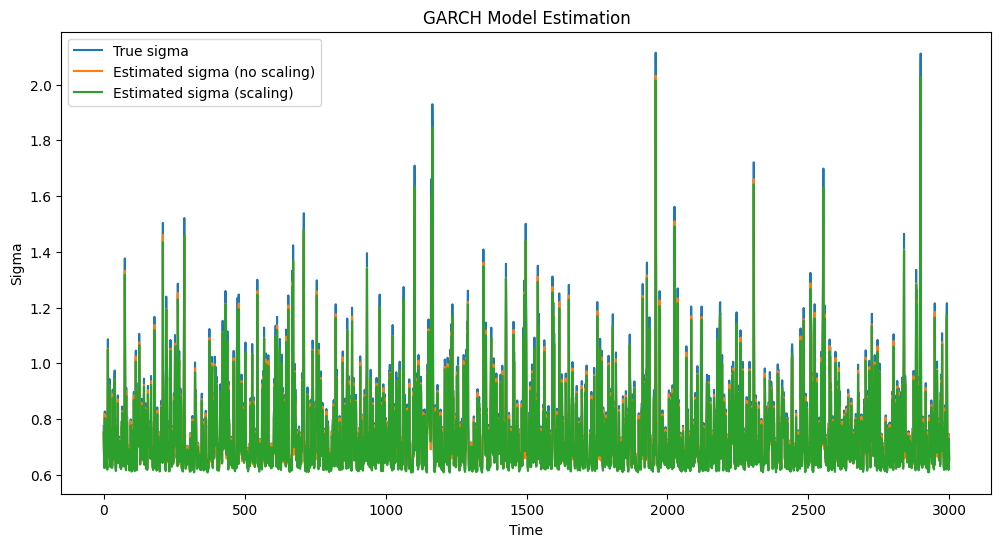

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(sigma, label='True sigma')
plt.plot(sigmas_hat, label='Estimated sigma (no scaling)')
plt.plot(sigmas_hat_scaling, label='Estimated sigma (scaling)')
plt.xlabel('Time')
plt.ylabel('Sigma')
plt.title('GARCH Model Estimation')
plt.legend()
plt.show()

### Проверяю, есть ли разница в сходимости параметров при скейлинге

In [ ]:
def compare_garch_estimation_stability(omega, alpha, beta, N=20000, step=100, seed=42):
    """
    Сравнивает стабильность оценок estimate_garch11 и scaling_estimate_garch11_norm
    на срезах растущей длины.

    Returns:
        errors_plain, errors_scaling — 1D arrays длины N//step,
        каждый элемент = aggregate MAE по omega, alpha, beta на данном срезе.
    """
    np.random.seed(seed)
    x, _, _ = garch_11_norm_sample(N, omega, alpha, beta) # генерируем последовательность

    slice_sizes = list(range(step, N + 1, step)) # размеры срезов от 100 до N с шагом 100

    errors_plain   = np.empty(len(slice_sizes))
    errors_scaling = np.empty(len(slice_sizes))

    # per-param errors для детализированных графиков
    err_plain_omega  = np.empty(len(slice_sizes))
    err_plain_alpha  = np.empty(len(slice_sizes))
    err_plain_beta   = np.empty(len(slice_sizes))
    err_scaling_omega = np.empty(len(slice_sizes))
    err_scaling_alpha = np.empty(len(slice_sizes))
    err_scaling_beta  = np.empty(len(slice_sizes))

    for i, size in enumerate(slice_sizes):
        x_slice = x[:size]

        res_p = estimate_garch11(x_slice)
        res_s = scaling_estimate_garch11_norm(x_slice)

        dpo = abs(res_p['omega'] - omega)
        dpa = abs(res_p['alpha'] - alpha)
        dpb = abs(res_p['beta']  - beta)

        dso = abs(res_s['omega'] - omega)
        dsa = abs(res_s['alpha'] - alpha)
        dsb = abs(res_s['beta']  - beta)

        errors_plain[i]   = (dpo + dpa + dpb) / 3
        errors_scaling[i] = (dso + dsa + dsb) / 3

        err_plain_omega[i]  = dpo
        err_plain_alpha[i]  = dpa
        err_plain_beta[i]   = dpb
        err_scaling_omega[i] = dso
        err_scaling_alpha[i] = dsa
        err_scaling_beta[i]  = dsb

    # --- визуализация ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    xs = slice_sizes

    kw_plain   = dict(color='blue',  label='no scaling', linewidth=1.2)
    kw_scaling = dict(color='red',   label='scaling x100', linewidth=1.2, linestyle='--')

    # aggregate MAE
    axes[0, 0].plot(xs, errors_plain,   **kw_plain)
    axes[0, 0].plot(xs, errors_scaling, **kw_scaling)
    axes[0, 0].set_title('Aggregate MAE (mean over ω, α, β)')
    axes[0, 0].set_xlabel('Sample size')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.4)

    # omega
    axes[0, 1].plot(xs, err_plain_omega,  **kw_plain)
    axes[0, 1].plot(xs, err_scaling_omega, **kw_scaling)
    axes[0, 1].set_title(f'|ω̂ − ω|  (true ω = {omega})')
    axes[0, 1].set_xlabel('Sample size')
    axes[0, 1].set_ylabel('Absolute error')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.4)

    # alpha
    axes[1, 0].plot(xs, err_plain_alpha,  **kw_plain)
    axes[1, 0].plot(xs, err_scaling_alpha, **kw_scaling)
    axes[1, 0].set_title(f'|α̂ − α|  (true α = {alpha})')
    axes[1, 0].set_xlabel('Sample size')
    axes[1, 0].set_ylabel('Absolute error')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.4)

    # beta
    axes[1, 1].plot(xs, err_plain_beta,  **kw_plain)
    axes[1, 1].plot(xs, err_scaling_beta, **kw_scaling)
    axes[1, 1].set_title(f'|β̂ − β|  (true β = {beta})')
    axes[1, 1].set_xlabel('Sample size')
    axes[1, 1].set_ylabel('Absolute error')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.4)

    plt.suptitle(
        f'GARCH(1,1) estimation stability: no scaling vs scaling x100\n'
        f'true params: ω={omega}, α={alpha}, β={beta}',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    return errors_plain, errors_scaling


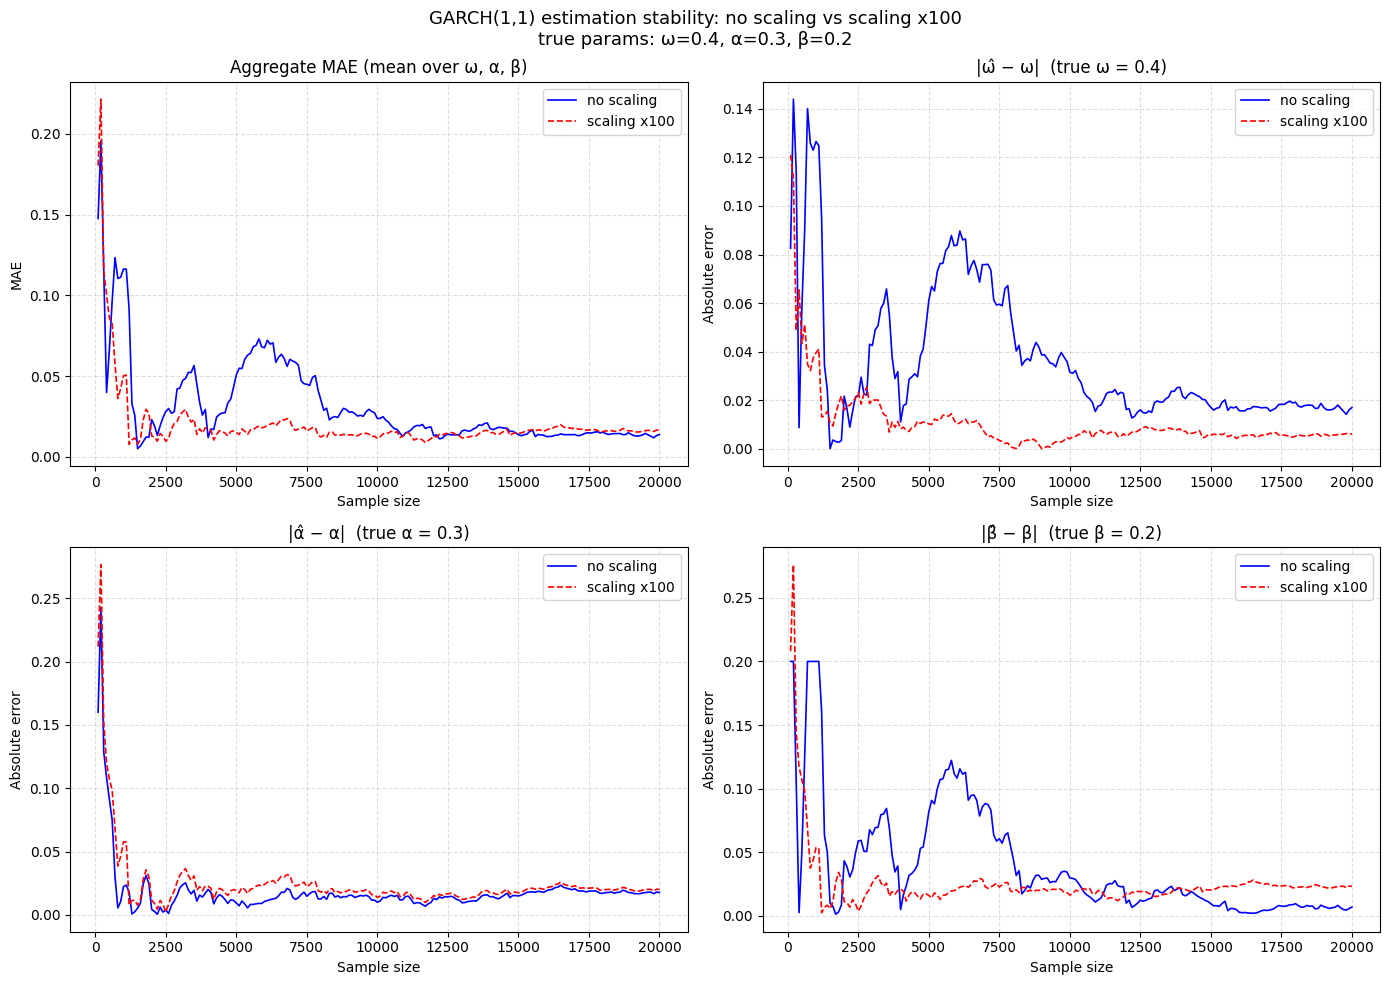

errors_plain.shape:   (200,)
errors_scaling.shape: (200,)


In [12]:
errors_plain, errors_scaling = compare_garch_estimation_stability(
    omega=0.4, alpha=0.3, beta=0.2
)

print(f"errors_plain.shape:   {errors_plain.shape}")
print(f"errors_scaling.shape: {errors_scaling.shape}")

# видно, что с масштабированием оценки гораздо стабильнее
# поэтому дальше будем работать с масштабированием 


### Обычный GARCH --- скользяшая оценка квантилей 

In [ ]:
## проходимся скользящим окном

def rolling_estimate_vanila_garch11(r, window, alpha):
    """
    Квантильная оценка GARCH(1,1) скользящим окном.

    Args:
        r: array-like, временной ряд
        window: int, размер окна

    Returns:
        
    """

    quantile = norm.ppf(alpha)

    r = np.asarray(r, dtype=float)
    n = len(r)

    r_quantile = np.full(n + 1, np.nan) # сюда сложу квантили условного распределения на шаг t + 1

    for t in range(window, n + 1): # в этот цикл хочу вставить подсчет след 
        # текущее окно -- обрабатываем отрезок от 
        r_window = r[t - window:t] # от 0 до window-1, от 1 до window + 1, от 2 до window + 2, ...

        # оцениваем GARCH на окне
        res = scaling_estimate_garch11_norm(r_window)

        # запоминаем оцененные параметры: 
        omega_hat = res['omega']
        alpha_hat = res['alpha']
        beta_hat = res['beta']
        sigmas_hat = res['sigmas']

        sigma_t_plus1_hat = (omega_hat + alpha_hat * r_window[-1]**2 + beta_hat * sigmas_hat[-1]**2)**0.5
        
        r_quantile[t] = sigma_t_plus1_hat * quantile
    
    return r_quantile


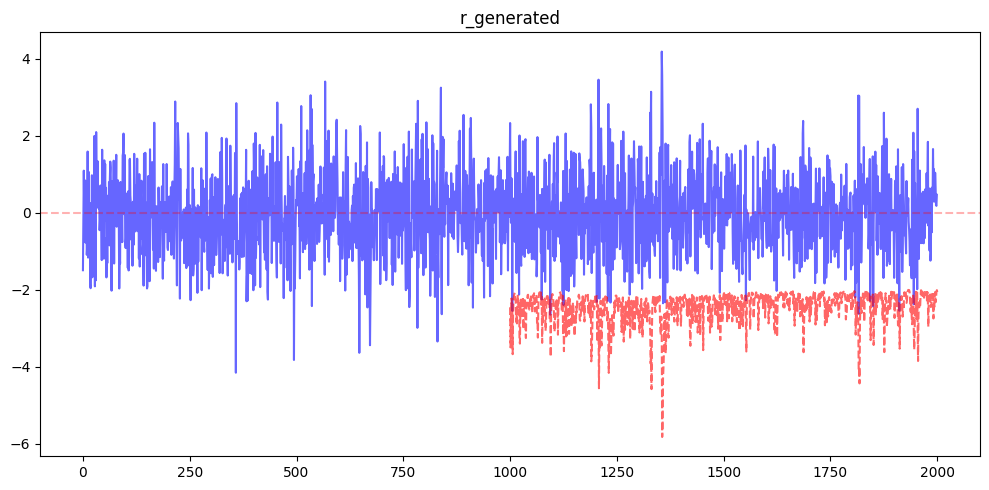

Доля превышений: 0.5%, уровень значимости: 1%.


In [25]:
# тест на генерации на норм шуме

## генерация
true_omega = 0.6
true_alpha = 0.3
true_beta = 0.2
N = 2000

r = garch_11_norm_sample(N, true_omega, true_alpha, true_beta)[0]

# оценка
alpha = 0.01
window = 1000
r_quantile = rolling_estimate_vanila_garch11(r, window, alpha)

# графики
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.plot(r, color='blue', alpha=0.6)
axes.plot(r_quantile, color='red', linestyle='--', alpha=0.6)
axes.axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes.set_title('r_generated')

plt.tight_layout()
plt.show()


# доля превышений:
r_compare = r[window: N]
r_quantile_compare = r_quantile[window: N]

mask = r_compare < r_quantile_compare

over_value_share = (mask.sum() / len(mask))*100

print('='*30)
print(f'Доля превышений: {over_value_share}%, уровень значимости: {1}%.')

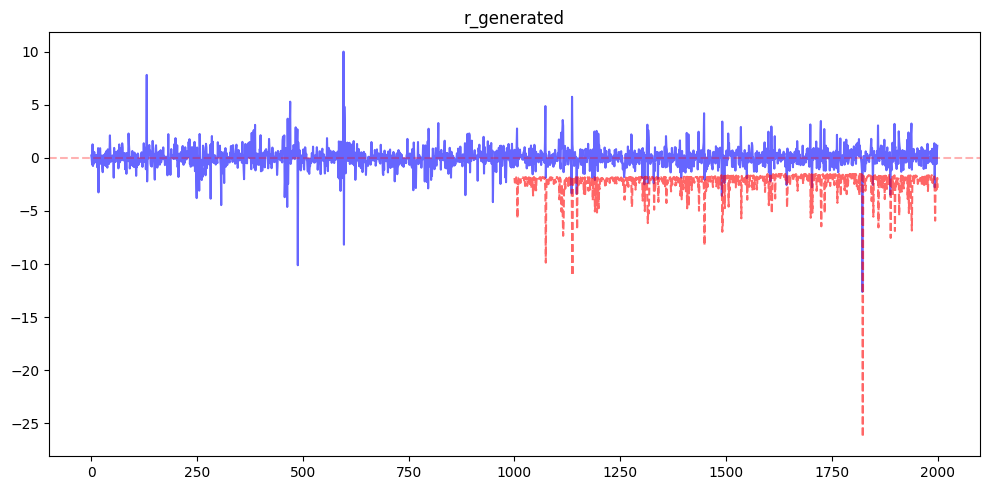

Доля превышений: 1.3%, уровень значимости: 1%.


In [14]:
# тест на генерации на стьюденте

## генерация
true_omega = 0.6
true_alpha = 0.3
true_beta = 0.2
df = 3
N = 2000

r = garch_11_stud_sample(N, true_omega, true_alpha, true_beta, df)[0]

# оценка
alpha = 0.01
window = 1000
r_quantile = rolling_estimate_vanila_garch11(r, window, alpha)

# графики
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.plot(r, color='blue', alpha=0.6)
axes.plot(r_quantile, color='red', linestyle='--', alpha=0.6)
axes.axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes.set_title('r_generated')

plt.tight_layout()
plt.show()


# доля превышений:
r_compare = r[window: N]
r_quantile_compare = r_quantile[window: N]

mask = r_compare < r_quantile_compare

over_value_share = (mask.sum() / len(mask))*100

print('='*30)
print(f'Доля превышений: {over_value_share}%, уровень значимости: {1}%.')

### GARCH-EVA: оценка распределением Гумбеля

In [28]:
def block_maxima(arr, k):
    n = len(arr)
    num_blocks = n // k  # остаток отбрасывается
    trimmed = arr[:num_blocks * k]
    blocks = trimmed.reshape(num_blocks, k)
    return blocks.max(axis=1)

# нормирующие константы из теоремы 
# вместо n надо посдавлять число блоков
def c_n(n):
    return np.sqrt(2 * np.log(n)) - (np.log(np.log(n)) + np.log(4 * np.pi)) / (2 * np.sqrt(2 * np.log(n)))

def d_n(n):
    return np.sqrt(2 * np.log(n))

# d_n(n) * (M - c_n(n))

In [39]:
## вопрос: действительно ли блок-максима остатков похожи на гумбеля? посмотрим на однократную оценку

## генерация
true_omega = 0.4
true_alpha = 0.3
true_beta = 0.2
N = 1000000

r = garch_11_norm_sample(N, true_omega, true_alpha, true_beta)[0]

res = estimate_garch11(r)
sigma_hat = res['sigmas']

resid = r / sigma_hat
k = 500
maxima = block_maxima(resid, k)

norm_maxima = d_n(len(maxima)) * (maxima - c_n(len(maxima)))

μ (loc)   = -1.7213
β (scale) = 1.2228


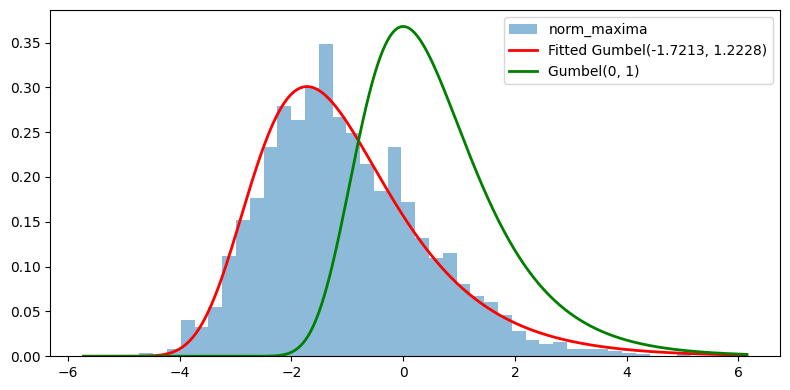

In [45]:
from scipy.stats import gumbel_r

x = np.linspace(norm_maxima.min() - 1, norm_maxima.max() + 1, 500)

mu, beta = gumbel_r.fit(norm_maxima)
print(f"μ (loc)   = {mu:.4f}")
print(f"β (scale) = {beta:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(norm_maxima, bins=40, density=True, alpha=0.5, label='norm_maxima')
ax.plot(x, gumbel_r.pdf(x, loc=mu, scale=beta), lw=2, color='red', label=f'Fitted Gumbel({mu:.4f}, {beta:.4f})')
ax.plot(x, gumbel_r.pdf(x, loc=0, scale=1), lw=2, color='green', label='Gumbel(0, 1)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# теперь для минимумов 

def block_minima(arr, k):
    n = len(arr)
    num_blocks = n // k  # остаток отбрасывается
    trimmed = arr[:num_blocks * k]
    blocks = trimmed.reshape(num_blocks, k)
    return blocks.min(axis=1)

In [55]:
minima = block_minima(resid, k)

norm_minima = d_n(len(minima)) * (minima - c_n(len(minima)))

μ (loc)   = -24.1135
β (scale) = 1.2096


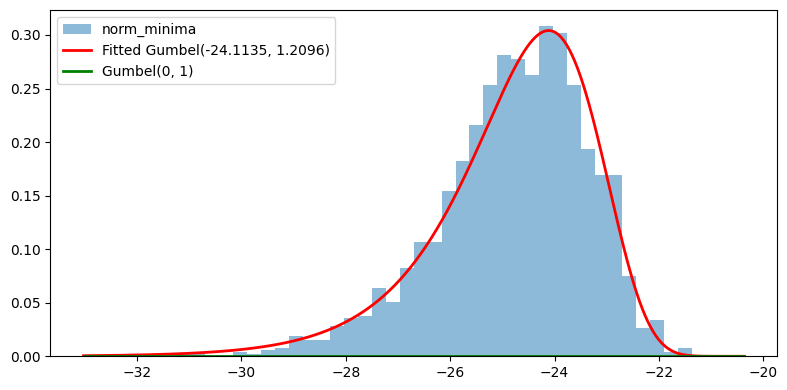

In [ ]:
from scipy.stats import gumbel_l

x = np.linspace(norm_minima.min() - 1, norm_minima.max() + 1, 500)

mu, beta = gumbel_l.fit(norm_minima)
print(f"μ (loc)   = {mu:.4f}")
print(f"β (scale) = {beta:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(norm_minima, bins=40, density=True, alpha=0.5, label='norm_minima')
ax.plot(x, gumbel_l.pdf(x, loc=mu, scale=beta), lw=2, color='red', label=f'Fitted Gumbel({mu:.4f}, {beta:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
## пишем функцию для GARCH-EVA-оценки скользящим окном 

def rolling_estimate_garch_eva11(r, window, alpha, block_size):
    """
    Скользящая оценка GARCH-EVA(1,1) на основе минимумов.

    Args:
        r: array-like, временной ряд
        window: int, размер окна для оценки GARCH
        alpha: float, уровень значимости для квантиля
        block_size: int, размер блока для блочного минимума
    """  
    quantile = norm.ppf(alpha)

    r = np.asarray(r, dtype=float)
    n = len(r)

    r_quantile = np.full(n + 1, np.nan) # сюда сложу квантили условного распределения на шаг t + 1

    for t in range(window, n + 1): 
        r_window = r[t - window:t] 

        res = scaling_estimate_garch11_norm(r_window)

        omega_hat = res['omega']
        alpha_hat = res['alpha']
        beta_hat = res['beta']
        sigmas_hat = res['sigmas']

        resid_window = r_window / sigmas_hat

        minima = block_minima(resid_window, block_size)
        norm_minima = d_n(len(minima)) * (minima - c_n(len(minima)))

        mu, beta_evt = gumbel_l.fit(norm_minima)

        sigma_t_plus1_hat = (omega_hat + alpha_hat * r_window[-1]**2 + beta_hat * sigmas_hat[-1]**2)**0.5
        
        r_quantile[t] = sigma_t_plus1_hat * gumbel_l.ppf(alpha / len(minima), loc=mu, scale=beta_evt)
    
    return r_quantile

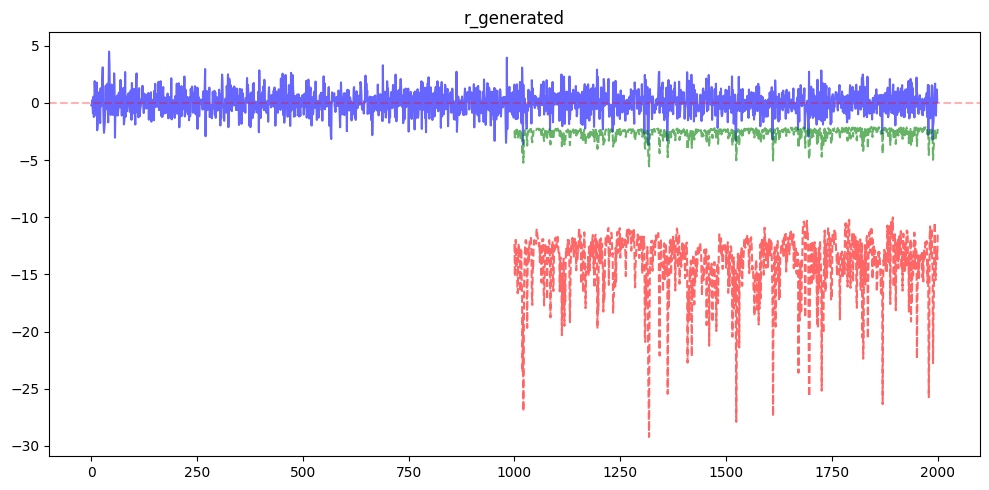

Доля превышений для GARCH-EVA: 0.0%, уровень значимости: 0.5%.
Доля превышений для vanilla GARCH: 0.7000000000000001%, уровень значимости: 0.5%.


In [65]:
# тест на генерации на норм шуме

## генерация
true_omega = 0.6
true_alpha = 0.3
true_beta = 0.2
N = 2000

r = garch_11_norm_sample(N, true_omega, true_alpha, true_beta)[0]

# оценка
alpha = 0.005
window = 1000
block_size = 100
r_quantile_eva = rolling_estimate_garch_eva11(r, window, alpha, block_size)
r_quantile_vanilla = rolling_estimate_vanila_garch11(r, window, alpha)

# графики
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.plot(r, color='blue', alpha=0.6)
axes.plot(r_quantile_eva, color='red', linestyle='--', alpha=0.6)
axes.plot(r_quantile_vanilla, color='green', linestyle='--', alpha=0.6)
axes.axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes.set_title('r_generated')

plt.tight_layout()
plt.show()


# доля превышений:
r_compare = r[window: N]
r_quantile_compare_eva = r_quantile_eva[window: N]
r_quantile_compare_vanilla = r_quantile_vanilla[window: N]

mask_eva = r_compare < r_quantile_compare_eva
mask_vanilla = r_compare < r_quantile_compare_vanilla

over_value_share_eva = (mask_eva.sum() / len(mask_eva))*100
over_value_share_vanilla = (mask_vanilla.sum() / len(mask_vanilla))*100

print('='*30)
print(f'Доля превышений для GARCH-EVA: {over_value_share_eva}%, уровень значимости: {alpha*100}%.')
print(f'Доля превышений для vanilla GARCH: {over_value_share_vanilla}%, уровень значимости: {alpha*100}%.')

### Пробую сделать оценку через r_nk: оценка максимального значения на 

$r_{nk}$ -- значение, которое пересекается в $1/k$ доле случаев на максимумах длины $n$. Полуачется, это значение превышается $1/nk$ доле случаев. 

план: 
1. По заданному перцентилю определяем $\alpha \to (k, n)$
2. Делим наблюдения на блоки и берем максимумы $r_t \to M_t$ 
3. Фиттим GEV $\to (\mu, \sigma, \xi)$
4. Считаем оцененный квантиль (формула + scipy)

In [45]:
from itertools import product


## функция для получения сетки параметров (k, n) для получения оценки r_nk
def alpha_to_nk(alpha):
    """
    Преобразует уровень значимости alpha в эффективный размер блока k для GARCH-EVA.

    Args:
        alpha: float, уровень значимости (например, 0.01)
    
    Returns:
        list of tuples (k, n), где n -- размер блока, а k -- нормирующая константа для оценки r_nk.
    """
    ans = []

    n_arr = [21, 63, 126, 252]  # возможные размеры блоков 
                                # (количество торговых дней в месяце, квартале, полугодии, году)
    for n in n_arr:
        k = 1 / (alpha * n)
        if k > 1: ans.append((k, n))
    
    return ans

In [46]:
# функция для деления наблюдений на блоки и получения максимумов в каждом блоке

def block_maxima(arr, n):
    """
    Делит массив arr на блоки размера n и возвращает массив максимумов 
    """
    len(arr)
    num_blocks = len(arr) // n  # остаток отбрасывается
    trimmed = arr[:num_blocks * n]
    blocks = trimmed.reshape(num_blocks, n)
    return blocks.max(axis=1)


In [47]:
# функция для получения оценки r_nk 
def return_r_nk(xi, mu, sigma, k):
    """
    Вычисляет оценку r_nk по оцененным параметрам (xi, mu, sigma, k)
    """
    return mu + (sigma / xi)*((-np.log(1 - 1/k))**(-xi) - 1)
    

In [68]:
from scipy.stats import genextreme

# одношаговая оценка r_nk 
 
alpha = 0.01
k_n_pairs = alpha_to_nk(alpha)

def r_kn_estimation(resid, k_n_pairs, sigma_t_plus1_hat):
    """
    Оценка r_kn для каждого (k, n) из k_n_pairs по остаткам resid. 
    Возвращает список оценок r_kn.
    """
    r_kn_estimates = []
    for k, n in k_n_pairs: 

        max_sample = block_maxima(resid, n) # делим на блоки и берем максимумы

        xi, loc, scale = genextreme.fit(max_sample) # оцениваем GEV
        xi = -xi # scipy возвращает параметр с противоположным знаком

        r_kn = return_r_nk(xi, loc, scale, k) # получаем оценку r_nk
        r_kn_estimates.append(r_kn)

    return np.array(r_kn_estimates) * sigma_t_plus1_hat

In [ ]:
## самая полная оценка: 

def rolling_estimate_garch_gev(r, alpha, window):
    """
    
    """
    n = len(r)
    quantile = norm.ppf(alpha) # квантиль для оценки GARCH-ваниллы
    r_quantile = np.full(n + 1, np.nan)
    k_n_pairs = alpha_to_nk(alpha) 
    r_kn = np.full((n + 1, len(k_n_pairs)), np.nan) # массив для оценок r_kn для каждой пары (k, n)

    quantile_estimations_result = {
        'vanila_garch_norm' : []
        , 'vanila_garch_stud': []
    }

    for t in range(window, n + 1): # в этот цикл хочу вставить подсчет след 
        # Шаг 0: обрезаем окно до того 
        r_window = r[t - window:t] # от 0 до window-1, от 1 до window + 1, от 2 до window + 2, ...

        # Шаг 1: GARCH-фильтрация на окне
        res = scaling_estimate_garch11_norm(r_window)

        # запоминаем оцененные параметры: 
        omega_hat = res['omega']
        alpha_hat = res['alpha']
        beta_hat = res['beta']
        sigmas_hat = res['sigmas']

        # Шаг 3: делаем квантильную оценку
        sigma_t_plus1_hat = (omega_hat + alpha_hat * r_window[-1]**2 + beta_hat * sigmas_hat[-1]**2)**0.5
        r_quantile[t] = sigma_t_plus1_hat * quantile

        # Шаг 4: получаем r_kn оценки 
        resid = r_window / sigmas_hat
        r_kn[t, :] = r_kn_estimation(resid, k_n_pairs, sigma_t_plus1_hat)
    
    return r_quantile, r_kn, k_n_pairs



In [73]:
N = 5000
true_omega, true_alpha, true_beta = 0.4, 0.3, 0.2
r = garch_11_norm_sample(N, true_omega, true_alpha, true_beta)[0]

alpha = 0.01    
window = 2500

r_quantile, r_kn, k_n_pairs = rolling_estimate_garch_gev(r, alpha, window)

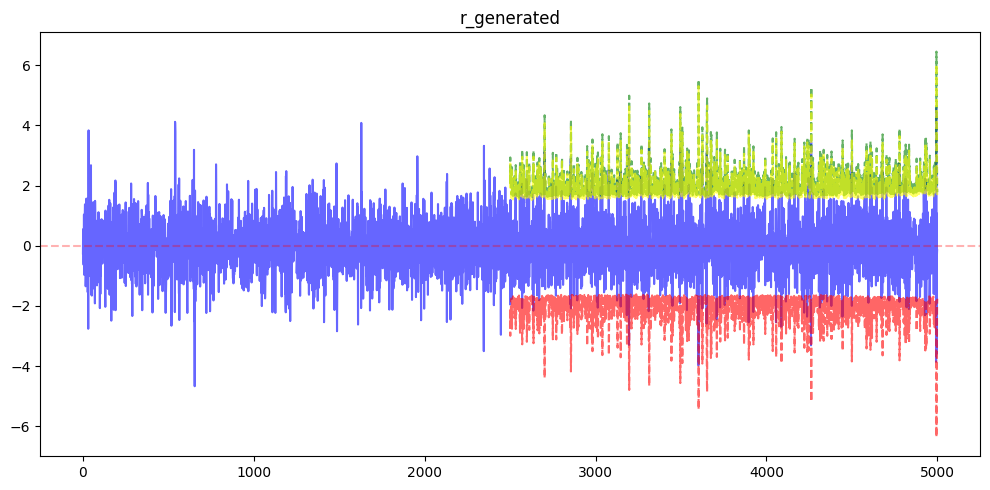

In [74]:
# графики
fig, axes = plt.subplots(1, 1, figsize=(10, 5))
axes.plot(r, color='blue', alpha=0.6)
axes.plot(r_quantile, color='red', linestyle='--', alpha=0.6)
axes.plot(r_kn[:, 0], color='green', linestyle='--', alpha=0.6)
axes.plot(r_kn[:, 1], color='yellow', linestyle='--', alpha=0.6)
axes.axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes.set_title('r_generated')

plt.tight_layout()
plt.show()

In [ ]:
# доля превышений:
r_compare = r[window: N]
r_quantile_compare_vanila = r_quantile[window: N]
r_quantile_compare_rkn_0 = r_kn[:, 0][window: N]
r_quantile_compare_rkn_1 = r_kn[:, 1][window: N]

mask_vanilla = r_compare < r_quantile_compare_vanila
mask_rkn_0 = r_compare < r_quantile_compare_rkn_0
mask_rkn_1 = r_compare < r_quantile_compare_rkn_1

over_value_share_vanilla = (mask_vanilla.sum() / len(mask_vanilla))*100
over_value_share_rkn_0 = (mask_rkn_0.sum() / len(mask_rkn_0))*100
over_value_share_rkn_1 = (mask_rkn_1.sum() / len(mask_rkn_1))*100

print('='*30)
print(f'Доля превышений для vanilla GARCH: {over_value_share_vanilla}%, уровень значимости: {alpha*100}%.')
print(f'Доля превышений для r_kn (k=0): {over_value_share_rkn_0}%, уровень значимости: {alpha*100}%.')
print(f'Доля превышений для r_kn (k=1): {over_value_share_rkn_1}%, уровень значимости: {alpha*100}%.')

Доля превышений для vanilla GARCH: 0.88%, уровень значимости: 1.0%.
Доля превышений для RKN (k=0): 98.8%, уровень значимости: 1.0%.
Доля превышений для RKN (k=1): 98.52%, уровень значимости: 1.0%.
